Dependencies


In [ ]:
!pip install -q --no-cache-dir torch==2.5.1 torchvision==0.20.1 --extra-index-url https://download.pytorch.org/whl/cu121 && pip install -q "numpy<2.0.0,>=1.26.0" "transformers<4.48.0" "peft<0.14.0" "f5-tts>=0.3.4" vocos encodec safetensors accelerate soundfile librosa pandas

In [ ]:
!pip install -q --no-cache-dir torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --extra-index-url https://download.pytorch.org/whl/cu121 && pip install -q --no-build-isolation "numpy<2.0.0,>=1.26.0" "transformers<4.48.0" "peft<0.14.0" "f5-tts>=0.3.4" vocos encodec safetensors accelerate soundfile librosa pandas

hUGGING FACE LOGIN

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

dEPENDENCIES

In [ ]:
# 1. Remove the mismatched generic f5-tts package
!pip uninstall -y f5-tts -q

# 2. ffmpeg is required by IndicF5's audio pipeline (usually preinstalled on Kaggle, but confirm)
!apt-get -y -qq install ffmpeg > /dev/null 2>&1

# 3. Install AI4Bharat's own IndicF5 package — --no-deps to protect your
#    already-working torch/torchvision GPU pairing
!pip install -q --no-deps git+https://github.com/ai4bharat/IndicF5.git

# 4. torchcodec is used by some audio-loading code paths in this package
!pip install -q --no-deps torchcodec

In [ ]:
# ===========================================================================
# IndicF5 + LoRA fine-tuning — full verified dependency install
# Run this as the FIRST cell in a fresh Kaggle session (GPU accelerator on).
# Do NOT reinstall torch/torchvision/torchaudio — Kaggle's preinstalled
# GPU-matched trio must stay untouched, or everything below breaks.
# ===========================================================================

# 1. System dependency
!apt-get -y -qq install ffmpeg > /dev/null 2>&1

# 2. Remove the generic PyPI f5-tts package if present — it's API-incompatible
#    with IndicF5's custom modeling code (different load_model signature)
!pip uninstall -y f5-tts -q

# 3. Install AI4Bharat's own IndicF5 package from GitHub — this is the
#    version their model.py actually expects, not the generic PyPI package.
#    --no-deps is critical: without it, this pulls its own torch/torchaudio
#    and breaks the GPU-matched pair Kaggle already set up.
!pip install -q --no-deps git+https://github.com/ai4bharat/IndicF5.git

# 4. IndicF5's audio loading path needs torchcodec
!pip install -q --no-deps torchcodec

# 5. Pinned transformers/accelerate/peft — installed individually with
#    --no-deps so a version conflict in one doesn't cascade into the others
#    or drag in a mismatched torch
!pip install -q --no-deps transformers==4.50.0
!pip install -q --no-deps "accelerate==0.34.2"
!pip install -q --no-deps peft==0.13.2

# 6. Lightweight packages with no torch-version sensitivity — safe to
#    install normally (with deps)
!pip install -q safetensors==0.4.5 soundfile==0.12.1 librosa==0.10.2.post1

# 7. transformers==4.50.0 requires tokenizers<0.22 specifically — force
#    the correct version, since other packages tend to pull it back to
#    a newer incompatible one
!pip install -q --no-deps --force-reinstall "tokenizers==0.21.4"

# ===========================================================================
# Verification — run this in a SEPARATE cell after a session restart
# (Run -> Restart Session, not Factory Reset — that would wipe these installs)
# ===========================================================================

In [2]:
# Print every submodule name containing "proj", "attn", "linear", or similar —
# this will show us the real names to target for LoRA on this specific class.
import re

proj_like_modules = []
for name, module in base_model.named_modules():
    if re.search(r"proj|attn|linear|to_q|to_k|to_v|qkv|wq|wk|wv", name, re.IGNORECASE):
        proj_like_modules.append((name, type(module).__name__))

print(f"Found {len(proj_like_modules)} candidate modules:\n")
for name, cls in proj_like_modules[:60]:
    print(f"{name}  ->  {cls}")

Found 245 candidate modules:

ema_model._orig_mod.transformer.input_embed.proj  ->  Linear
ema_model._orig_mod.transformer.transformer_blocks.0.attn_norm  ->  AdaLayerNormZero
ema_model._orig_mod.transformer.transformer_blocks.0.attn_norm.silu  ->  SiLU
ema_model._orig_mod.transformer.transformer_blocks.0.attn_norm.linear  ->  Linear
ema_model._orig_mod.transformer.transformer_blocks.0.attn_norm.norm  ->  LayerNorm
ema_model._orig_mod.transformer.transformer_blocks.0.attn  ->  Attention
ema_model._orig_mod.transformer.transformer_blocks.0.attn.to_q  ->  Linear
ema_model._orig_mod.transformer.transformer_blocks.0.attn.to_k  ->  Linear
ema_model._orig_mod.transformer.transformer_blocks.0.attn.to_v  ->  Linear
ema_model._orig_mod.transformer.transformer_blocks.0.attn.to_out  ->  ModuleList
ema_model._orig_mod.transformer.transformer_blocks.0.attn.to_out.0  ->  Linear
ema_model._orig_mod.transformer.transformer_blocks.0.attn.to_out.1  ->  Dropout
ema_model._orig_mod.transformer.transformer

In [3]:
for name, _ in base_model.named_children():
    print(name)

print("\n--- one level deeper into ema_model ---")
if hasattr(base_model, "ema_model"):
    for name, _ in base_model.ema_model.named_children():
        print(" ", name)

vocoder
ema_model

--- one level deeper into ema_model ---
  _orig_mod


In [4]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],  # real attention projection names for this architecture
    lora_dropout=0.05,
    bias="none"
)

In [5]:
# Unwrap torch.compile before LoRA injection — avoids graph-break /
# stale-compiled-graph issues when training with newly injected LoRA layers
if hasattr(base_model.ema_model, "_orig_mod"):
    base_model.ema_model = base_model.ema_model._orig_mod
    print("Unwrapped torch.compile from ema_model.")

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
model = model.to(DEVICE)

Unwrapped torch.compile from ema_model.
trainable params: 2,883,584 || all params: 353,512,038 || trainable%: 0.8157


In [6]:
import inspect

# Check the actual forward signature and body of the wrapper class
print("=== INF5Model.forward ===")
print(inspect.signature(base_model.forward))
print()
print(inspect.getsource(base_model.forward))

=== INF5Model.forward ===
(text: str, ref_audio_path: str, ref_text: str)

    def forward(self, text: str, ref_audio_path: str, ref_text: str):
        """
        Generate speech given a reference audio & text input.
        
        Args:
            text (str): The text to be synthesized.
            ref_audio_path (str): Path to the reference audio file.
            ref_text (str): The reference text.

        Returns:
            np.array: Generated waveform.
        """

        if not os.path.exists(ref_audio_path):
            raise FileNotFoundError(f"Reference audio file {ref_audio_path} not found.")

        # Load reference audio & text
        ref_audio, ref_text = preprocess_ref_audio_text(ref_audio_path, ref_text)

        
        self.ema_model.to(self.device)
        self.vocoder.to(self.device)
        
        # Perform inference
        audio, final_sample_rate, _ = infer_process(
            ref_audio,
            ref_text,
            text,
            self.ema_

In [7]:
print("=== ema_model (CFM) — public methods ===")
cfm = base_model.ema_model
for name in dir(cfm):
    if not name.startswith("_") and callable(getattr(cfm, name)):
        print(name)

print("\n=== ema_model.forward signature ===")
print(inspect.signature(cfm.forward))

=== ema_model (CFM) — public methods ===
add_module
apply
bfloat16
buffers
children
compile
cpu
cuda
double
eval
extra_repr
float
forward
get_buffer
get_extra_state
get_parameter
get_submodule
half
ipu
load_state_dict
mel_spec
modules
mtia
named_buffers
named_children
named_modules
named_parameters
parameters
register_backward_hook
register_buffer
register_forward_hook
register_forward_pre_hook
register_full_backward_hook
register_full_backward_pre_hook
register_load_state_dict_post_hook
register_load_state_dict_pre_hook
register_module
register_parameter
register_state_dict_post_hook
register_state_dict_pre_hook
requires_grad_
sample
set_extra_state
set_submodule
share_memory
state_dict
to
to_empty
train
transformer
type
xpu
zero_grad

=== ema_model.forward signature ===
(inp: "float['b n d'] | float['b nw']", text: "int['b nt'] | list[str]", *, lens: "int['b'] | None" = None, noise_scheduler: 'str | None' = None)


In [8]:
model.train()  # ensure LoRA dropout etc. are active

# Grab one real batch from your existing dataloader
sample_audios, sample_texts, sample_lengths = next(iter(dataloader))
sample_audios = sample_audios.to(DEVICE)
sample_lengths = sample_lengths.to(DEVICE)

print("audios shape:", sample_audios.shape)
print("lengths:", sample_lengths)
print("texts:", sample_texts)

output = base_model.ema_model(sample_audios, sample_texts, lens=sample_lengths)

print("\n--- Output structure ---")
print("type:", type(output))
if isinstance(output, tuple):
    for i, item in enumerate(output):
        if torch.is_tensor(item):
            print(f"  [{i}] tensor, shape={item.shape}, requires_grad={item.requires_grad}")
        else:
            print(f"  [{i}] {type(item)}")
elif torch.is_tensor(output):
    print(f"  tensor, shape={output.shape}, requires_grad={output.requires_grad}")

NameError: name 'dataloader' is not defined

In [10]:
import os

DATASET_DIR = "/kaggle/input/datasets/thor18124/hellooo/tts-dataset"
TRANSCRIPTS_PATH = os.path.join(DATASET_DIR, "transcripts.csv")

# Verify before rebuilding the Dataset — confirms structure matches what
# TamilTTSDataset expects (wavs/<speaker>/<file>.wav layout)
print("Dataset dir exists:", os.path.exists(DATASET_DIR))
print("Transcripts CSV exists:", os.path.exists(TRANSCRIPTS_PATH))
print("\nTop-level contents:", os.listdir(DATASET_DIR))
print("\nSample speaker folders in wavs/:", os.listdir(os.path.join(DATASET_DIR, "wavs"))[:15])

Dataset dir exists: True
Transcripts CSV exists: True

Top-level contents: ['transcripts.xlsx', 'transcripts.csv', 'params.json', 'clips_qc.csv', 'wavs', 'rejected.csv', 'asr-cache.json', 'metadata.csv']

Sample speaker folders in wavs/: ['mohan', 'ruparagunath_g', 'balamurugan_t', 'speaker_c', 'kirithiga_v', 'dhanalakshmi', 'dhaya', 'speaker_b', 'speaker_a', 'karthik_raja_p', 'harish']


In [11]:
import pandas as pd
import torch
import librosa
from torch.utils.data import Dataset, DataLoader

class TamilTTSDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, sample_rate=24000):
        self.df = pd.read_csv(csv_path, encoding="utf-8")
        if 'duration_s' in self.df.columns:
            self.df = self.df[(self.df['duration_s'] >= 1.0) & (self.df['duration_s'] <= 12.0)].reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.sample_rate = sample_rate

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_rel_path = str(row['audio_file'])
        audio_path = os.path.join(self.dataset_dir, audio_rel_path)

        if not os.path.exists(audio_path):
            audio_path = os.path.join(self.dataset_dir, "wavs", os.path.basename(audio_rel_path))

        y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
        text = str(row['text']).strip()

        return torch.tensor(y, dtype=torch.float32), text

def collate_fn(batch):
    audios, texts = zip(*batch)
    lengths = [len(a) for a in audios]
    max_len = max(lengths)

    padded_audios = torch.zeros(len(audios), max_len, dtype=torch.float32)
    for i, a in enumerate(audios):
        padded_audios[i, :len(a)] = a

    return padded_audios, list(texts), torch.tensor(lengths, dtype=torch.long)

dataset = TamilTTSDataset(TRANSCRIPTS_PATH, DATASET_DIR)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

print(f"\nDataset loaded: {len(dataset)} samples")
print(f"Dataloader ready: {len(dataloader)} batches")


Dataset loaded: 149 samples
Dataloader ready: 75 batches


In [12]:
df_check = pd.read_csv(TRANSCRIPTS_PATH, encoding="utf-8")
print(df_check['duration_s'].describe())

count    286.000000
mean      11.632080
std        4.868977
min        2.010000
25%        7.825000
50%       11.770000
75%       15.788000
max       19.980000
Name: duration_s, dtype: float64


In [13]:
# Optional: recover the excluded longer clips
class TamilTTSDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, sample_rate=24000):
        self.df = pd.read_csv(csv_path, encoding="utf-8")
        if 'duration_s' in self.df.columns:
            self.df = self.df[(self.df['duration_s'] >= 1.0) & (self.df['duration_s'] <= 20.0)].reset_index(drop=True)
        # ... rest unchanged

In [14]:
try:
    print(type(base_model))
    print(type(model))
    print("Both present.")
except NameError as e:
    print(f"Missing: {e}")

<class 'transformers_modules.ai4bharat.IndicF5.ba85abedf18dc479a447eaa0eccbd76ab78a47d5.model.INF5Model'>
<class 'peft.peft_model.PeftModel'>
Both present.


In [15]:
model.train()

sample_audios, sample_texts, sample_lengths = next(iter(dataloader))
sample_audios = sample_audios.to(DEVICE)
sample_lengths = sample_lengths.to(DEVICE)

print("audios shape:", sample_audios.shape)
print("lengths:", sample_lengths)
print("texts:", sample_texts)

output = base_model.ema_model(sample_audios, sample_texts, lens=sample_lengths)

print("\n--- Output structure ---")
print("type:", type(output))
if isinstance(output, tuple):
    for i, item in enumerate(output):
        if torch.is_tensor(item):
            print(f"  [{i}] tensor, shape={item.shape}, requires_grad={item.requires_grad}")
        else:
            print(f"  [{i}] {type(item)}")
elif torch.is_tensor(output):
    print(f"  tensor, shape={output.shape}, requires_grad={output.requires_grad}")

/tmp/ipykernel_415/4171896179.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/thor18124/hellooo/tts-dataset/wavs/pritvi__A1_literary_008.wav'

In [16]:
df_check = pd.read_csv(TRANSCRIPTS_PATH, encoding="utf-8")
print(df_check[['speaker', 'audio_file']].head(10))
print("\nColumns:", df_check.columns.tolist())

         speaker                                         audio_file
0  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
1  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
2  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
3  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
4  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
5  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
6  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
7  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
8  balamurugan_t  wavs/balamurugan_t/balamurugan_t__B1_colloquia...
9  balamurugan_t  wavs/balamurugan_t/balamurugan_t__A1_literary_...

Columns: ['audio_file', 'text', 'speaker', 'part', 'duration_s', 'snr_db', 'bandwidth_hz', 'loudness_gain_db', 'source_file', 'source_snr_db', 'declipped_runs', 'hum_notched_hz', 'atten_lim_db', 'speed', 'text_source', 'align_score', 'review', 'asr_hy

In [17]:
class TamilTTSDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, sample_rate=24000):
        self.df = pd.read_csv(csv_path, encoding="utf-8")
        if 'duration_s' in self.df.columns:
            self.df = self.df[(self.df['duration_s'] >= 1.0) & (self.df['duration_s'] <= 20.0)].reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.sample_rate = sample_rate

    def __len__(self):
        return len(self.df)

    def _resolve_audio_path(self, row):
        audio_rel_path = str(row['audio_file'])
        speaker = str(row['speaker']) if 'speaker' in row else None
        basename = os.path.basename(audio_rel_path)

        candidates = [
            os.path.join(self.dataset_dir, audio_rel_path),                              # as given in CSV
            os.path.join(self.dataset_dir, "wavs", audio_rel_path),                       # wavs/ + CSV value
            os.path.join(self.dataset_dir, "wavs", basename),                             # flat wavs/
        ]
        if speaker:
            candidates.append(os.path.join(self.dataset_dir, "wavs", speaker, basename))  # wavs/<speaker>/file
            candidates.append(os.path.join(self.dataset_dir, "wavs", speaker, audio_rel_path))

        for path in candidates:
            if os.path.exists(path):
                return path

        raise FileNotFoundError(
            f"Could not resolve audio file for row: audio_file={audio_rel_path!r}, speaker={speaker!r}. "
            f"Tried: {candidates}"
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = self._resolve_audio_path(row)
        y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
        text = str(row['text']).strip()
        return torch.tensor(y, dtype=torch.float32), text

dataset = TamilTTSDataset(TRANSCRIPTS_PATH, DATASET_DIR)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
print(f"Dataset loaded: {len(dataset)} samples")

Dataset loaded: 286 samples


In [18]:
missing_rows = []
for idx in range(len(dataset)):
    row = dataset.df.iloc[idx]
    try:
        dataset._resolve_audio_path(row)
    except FileNotFoundError as e:
        missing_rows.append((idx, str(row['audio_file']), str(row.get('speaker', '?'))))

print(f"Missing: {len(missing_rows)} / {len(dataset)}")
for idx, audio_file, speaker in missing_rows[:20]:
    print(f"  row {idx}: audio_file={audio_file!r}, speaker={speaker!r}")

Missing: 27 / 286
  row 160: audio_file='wavs/pritvi/pritvi__A1_literary_001.wav', speaker='pritvi'
  row 161: audio_file='wavs/pritvi/pritvi__A1_literary_002.wav', speaker='pritvi'
  row 162: audio_file='wavs/pritvi/pritvi__A1_literary_003.wav', speaker='pritvi'
  row 163: audio_file='wavs/pritvi/pritvi__A1_literary_004.wav', speaker='pritvi'
  row 164: audio_file='wavs/pritvi/pritvi__A1_literary_005.wav', speaker='pritvi'
  row 165: audio_file='wavs/pritvi/pritvi__A1_literary_006.wav', speaker='pritvi'
  row 166: audio_file='wavs/pritvi/pritvi__A1_literary_007.wav', speaker='pritvi'
  row 167: audio_file='wavs/pritvi/pritvi__A1_literary_008.wav', speaker='pritvi'
  row 168: audio_file='wavs/pritvi/pritvi__A1_literary_009.wav', speaker='pritvi'
  row 169: audio_file='wavs/pritvi/pritvi__A1_literary_010.wav', speaker='pritvi'
  row 170: audio_file='wavs/pritvi/pritvi__C1_personal-phrases_001.wav', speaker='pritvi'
  row 171: audio_file='wavs/pritvi/pritvi__C1_personal-phrases_002.wav',

In [19]:
import os
import pandas as pd
import torch
import librosa
from torch.utils.data import Dataset, DataLoader

DATASET_DIR = "/kaggle/input/datasets/thor18124/hellooo/tts-dataset"
TRANSCRIPTS_PATH = os.path.join(DATASET_DIR, "transcripts.csv")

class TamilTTSDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, sample_rate=24000):
        self.df = pd.read_csv(csv_path, encoding="utf-8")
        if 'duration_s' in self.df.columns:
            self.df = self.df[(self.df['duration_s'] >= 1.0) & (self.df['duration_s'] <= 20.0)].reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.sample_rate = sample_rate

    def __len__(self):
        return len(self.df)

    def _resolve_audio_path(self, row):
        audio_rel_path = str(row['audio_file'])
        speaker = str(row['speaker']) if 'speaker' in row else None
        basename = os.path.basename(audio_rel_path)

        candidates = [
            os.path.join(self.dataset_dir, audio_rel_path),
            os.path.join(self.dataset_dir, "wavs", audio_rel_path),
            os.path.join(self.dataset_dir, "wavs", basename),
        ]
        if speaker:
            candidates.append(os.path.join(self.dataset_dir, "wavs", speaker, basename))
            candidates.append(os.path.join(self.dataset_dir, "wavs", speaker, audio_rel_path))

        for path in candidates:
            if os.path.exists(path):
                return path

        raise FileNotFoundError(
            f"Could not resolve audio file for row: audio_file={audio_rel_path!r}, speaker={speaker!r}. "
            f"Tried: {candidates}"
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = self._resolve_audio_path(row)
        y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
        text = str(row['text']).strip()
        return torch.tensor(y, dtype=torch.float32), text

def collate_fn(batch):
    audios, texts = zip(*batch)
    lengths = [len(a) for a in audios]
    max_len = max(lengths)
    padded_audios = torch.zeros(len(audios), max_len, dtype=torch.float32)
    for i, a in enumerate(audios):
        padded_audios[i, :len(a)] = a
    return padded_audios, list(texts), torch.tensor(lengths, dtype=torch.long)

# --- Build dataset, then filter out unresolvable rows (pritvi, 27 rows) ---
dataset = TamilTTSDataset(TRANSCRIPTS_PATH, DATASET_DIR)
print(f"Before filtering: {len(dataset)} samples")

valid_indices = []
dropped = []
for idx in range(len(dataset)):
    row = dataset.df.iloc[idx]
    try:
        dataset._resolve_audio_path(row)
        valid_indices.append(idx)
    except FileNotFoundError:
        dropped.append(str(row.get('speaker', '?')))

dataset.df = dataset.df.iloc[valid_indices].reset_index(drop=True)

print(f"After filtering: {len(dataset)} samples")
print(f"Dropped: {len(dropped)} rows, speakers affected: {sorted(set(dropped))}")

dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
print(f"Dataloader ready: {len(dataloader)} batches")

# --- Speaker distribution check — confirms remaining speakers are well represented ---
print("\nSamples per speaker:")
print(dataset.df['speaker'].value_counts())

Before filtering: 286 samples
After filtering: 259 samples
Dropped: 27 rows, speakers affected: ['pritvi']
Dataloader ready: 130 batches

Samples per speaker:
speaker
balamurugan_t     58
ruparagunath_g    40
dhaya             31
dhanalakshmi      27
mohan             23
speaker_c         23
speaker_b         19
speaker_a         17
harish            16
karthik_raja_p     3
kirithiga_v        2
Name: count, dtype: int64


In [20]:
try:
    print(type(base_model)); print(type(model))
except NameError as e:
    print(f"Missing: {e} — rerun model load + LoRA injection cells first.")

<class 'transformers_modules.ai4bharat.IndicF5.ba85abedf18dc479a447eaa0eccbd76ab78a47d5.model.INF5Model'>
<class 'peft.peft_model.PeftModel'>


In [21]:
model.train()
sample_audios, sample_texts, sample_lengths = next(iter(dataloader))
sample_audios = sample_audios.to(DEVICE)
sample_lengths = sample_lengths.to(DEVICE)

print("audios shape:", sample_audios.shape)
print("lengths:", sample_lengths)
print("texts:", sample_texts)

output = base_model.ema_model(sample_audios, sample_texts, lens=sample_lengths)

print("\n--- Output structure ---")
print("type:", type(output))
if isinstance(output, tuple):
    for i, item in enumerate(output):
        if torch.is_tensor(item):
            print(f"  [{i}] tensor, shape={item.shape}, requires_grad={item.requires_grad}")
        else:
            print(f"  [{i}] {type(item)}")
elif torch.is_tensor(output):
    print(f"  tensor, shape={output.shape}, requires_grad={output.requires_grad}")

audios shape: torch.Size([2, 324000])
lengths: tensor([324000, 305856], device='cuda:0')
texts: ['முக்கியமான காரணமா என்று நினைக்குறாங்கன்னா, பெயர்ஸோடப் பவ்பார்மஞ்ச் ஏனா யார் மே வந்து அட்டட்டைம்ல இரண்டு மூன்று பெய்யர்கள் வந் து பவ்வாம் பண்ணல. யாறாச ஒருவர் தான் ஒரு மேச்சை பொள்ளா பகவ்ப் பணித்துவிட்டு போழ மாதிரி இருந்து.', 'நாளில் உனக்கு செல்வதற்கு மீண்டும், என் கொஞ்சத்தை லேங்சரியில் அழைப்பேன். பிறகு, நான் மோஸ்டிரைஜர் எடுக்கவேண்டியாக இருந்தேன்.']


RuntimeError: The size of tensor a (324000) must match the size of tensor b (1266) at non-singleton dimension 1

In [22]:
mel_module = base_model.ema_model.mel_spec
print("mel_spec type:", type(mel_module))
print("mel_spec signature:", inspect.signature(mel_module.forward))

# Run one waveform through it to see the actual output shape/orientation
with torch.no_grad():
    test_mel = mel_module(sample_audios)
print("\nInput waveform shape:", sample_audios.shape)
print("Output mel shape:", test_mel.shape)

mel_spec type: <class 'f5_tts.model.modules.MelSpec'>
mel_spec signature: (wav)

Input waveform shape: torch.Size([2, 324000])
Output mel shape: torch.Size([2, 100, 1266])


In [25]:
hop_length = 256
n_frames_total = mel.shape[1]

mel_lens = (sample_lengths // hop_length + 1).clamp(max=n_frames_total)

print("mel shape:", mel.shape)
print("mel_lens:", mel_lens)

output = base_model.ema_model(mel, sample_texts, lens=mel_lens)

print("\n--- Output structure ---")
print("type:", type(output))
if isinstance(output, tuple):
    for i, item in enumerate(output):
        if torch.is_tensor(item):
            print(f"  [{i}] tensor, shape={item.shape}, requires_grad={item.requires_grad}")
        else:
            print(f"  [{i}] {type(item)}")
elif torch.is_tensor(output):
    print(f"  tensor, shape={output.shape}, requires_grad={output.requires_grad}")

mel shape: torch.Size([2, 1266, 100])
mel_lens: tensor([1266, 1195], device='cuda:0')

--- Output structure ---
type: <class 'tuple'>
  [0] tensor, shape=torch.Size([]), requires_grad=True
  [1] tensor, shape=torch.Size([2, 1266, 100]), requires_grad=False
  [2] tensor, shape=torch.Size([2, 1266, 100]), requires_grad=True


wORKING CODE


In [26]:
import os
import time
import pandas as pd
import torch
import librosa
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ---------------------------------------------------------------------------
# Dataset (Option A: pritvi excluded due to missing audio files)
# ---------------------------------------------------------------------------
class TamilTTSDataset(Dataset):
    def __init__(self, csv_path, dataset_dir, sample_rate=24000):
        self.df = pd.read_csv(csv_path, encoding="utf-8")
        if 'duration_s' in self.df.columns:
            self.df = self.df[(self.df['duration_s'] >= 1.0) & (self.df['duration_s'] <= 20.0)].reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.sample_rate = sample_rate

    def __len__(self):
        return len(self.df)

    def _resolve_audio_path(self, row):
        audio_rel_path = str(row['audio_file'])
        speaker = str(row['speaker']) if 'speaker' in row else None
        basename = os.path.basename(audio_rel_path)
        candidates = [
            os.path.join(self.dataset_dir, audio_rel_path),
            os.path.join(self.dataset_dir, "wavs", audio_rel_path),
            os.path.join(self.dataset_dir, "wavs", basename),
        ]
        if speaker:
            candidates.append(os.path.join(self.dataset_dir, "wavs", speaker, basename))
            candidates.append(os.path.join(self.dataset_dir, "wavs", speaker, audio_rel_path))
        for path in candidates:
            if os.path.exists(path):
                return path
        raise FileNotFoundError(f"Unresolved: {audio_rel_path!r} / speaker={speaker!r}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = self._resolve_audio_path(row)
        y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
        text = str(row['text']).strip()
        return torch.tensor(y, dtype=torch.float32), text

def collate_fn(batch):
    audios, texts = zip(*batch)
    lengths = [len(a) for a in audios]
    max_len = max(lengths)
    padded_audios = torch.zeros(len(audios), max_len, dtype=torch.float32)
    for i, a in enumerate(audios):
        padded_audios[i, :len(a)] = a
    return padded_audios, list(texts), torch.tensor(lengths, dtype=torch.long)

DATASET_DIR = "/kaggle/input/datasets/thor18124/hellooo/tts-dataset"
TRANSCRIPTS_PATH = os.path.join(DATASET_DIR, "transcripts.csv")

dataset = TamilTTSDataset(TRANSCRIPTS_PATH, DATASET_DIR)
valid_indices = []
for idx in range(len(dataset)):
    try:
        dataset._resolve_audio_path(dataset.df.iloc[idx])
        valid_indices.append(idx)
    except FileNotFoundError:
        pass
dataset.df = dataset.df.iloc[valid_indices].reset_index(drop=True)
print(f"Dataset: {len(dataset)} samples")

dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# ---------------------------------------------------------------------------
# Confirm model + LoRA still in memory (rerun loading cells if not)
# ---------------------------------------------------------------------------
assert 'base_model' in dir() and 'model' in dir(), "Rerun model loading + LoRA injection cells first."

mel_module = base_model.ema_model.mel_spec
HOP_LENGTH = 256

# ---------------------------------------------------------------------------
# Training loop — using verified mel-spectrogram + frame-length conversion
# ---------------------------------------------------------------------------
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-2)

EPOCHS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model.train()
print(f"\nStarting LoRA fine-tuning: {len(dataset)} samples, {len(dataloader)} batches/epoch, {EPOCHS} epochs")

for epoch in range(EPOCHS):
    total_loss = 0.0
    epoch_start = time.time()

    for step, (audios, texts, lengths) in enumerate(dataloader):
        audios = audios.to(DEVICE)
        lengths = lengths.to(DEVICE)

        optimizer.zero_grad()

        # Convert raw waveform -> mel-spectrogram, matching the verified diagnostic
        with torch.no_grad():
            mel = mel_module(audios)              # [batch, n_mels, n_frames]
            mel = mel.transpose(1, 2)              # -> [batch, n_frames, n_mels]

        n_frames_total = mel.shape[1]
        mel_lens = (lengths // HOP_LENGTH + 1).clamp(max=n_frames_total)

        loss, cond, pred = base_model.ema_model(mel, texts, lens=mel_lens)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        if (step + 1) % 10 == 0 or (step + 1) == len(dataloader):
            print(f"Epoch [{epoch+1}/{EPOCHS}] | Step [{step+1}/{len(dataloader)}] | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    elapsed = time.time() - epoch_start
    print(f"--> Epoch {epoch+1} Average Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s")

# ---------------------------------------------------------------------------
# Save the trained LoRA adapter
# ---------------------------------------------------------------------------
OUTPUT_DIR = "/kaggle/working/indicf5_tamil_lora_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save_pretrained(OUTPUT_DIR)
print(f"\nTraining complete. LoRA adapter saved to: {OUTPUT_DIR}")

Dataset: 259 samples

Starting LoRA fine-tuning: 259 samples, 130 batches/epoch, 5 epochs
Epoch [1/5] | Step [10/130] | Loss: 0.4645
Epoch [1/5] | Step [20/130] | Loss: 0.7492
Epoch [1/5] | Step [30/130] | Loss: 0.6547
Epoch [1/5] | Step [40/130] | Loss: 0.6183
Epoch [1/5] | Step [50/130] | Loss: 0.4537
Epoch [1/5] | Step [60/130] | Loss: 2.2879
Epoch [1/5] | Step [70/130] | Loss: 1.3360
Epoch [1/5] | Step [80/130] | Loss: 0.8506
Epoch [1/5] | Step [90/130] | Loss: 0.4555
Epoch [1/5] | Step [100/130] | Loss: 0.7716
Epoch [1/5] | Step [110/130] | Loss: 0.5852
Epoch [1/5] | Step [120/130] | Loss: 0.5028
Epoch [1/5] | Step [130/130] | Loss: 0.7681
--> Epoch 1 Average Loss: 0.6945 | Time: 204.0s
Epoch [2/5] | Step [10/130] | Loss: 1.2876
Epoch [2/5] | Step [20/130] | Loss: 0.4665
Epoch [2/5] | Step [30/130] | Loss: 0.5288
Epoch [2/5] | Step [40/130] | Loss: 0.5031
Epoch [2/5] | Step [50/130] | Loss: 0.5675
Epoch [2/5] | Step [60/130] | Loss: 0.4440
Epoch [2/5] | Step [70/130] | Loss: 0.365

In [27]:
import os
import shutil
import json
import numpy as np
import soundfile as sf
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import FileLink

%matplotlib inline

# ===========================================================================
# 1. Save the trained LoRA adapter (should already exist from the training
#    cell, but safe to rerun)
# ===========================================================================
OUTPUT_DIR = "/kaggle/working/indicf5_tamil_lora_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save_pretrained(OUTPUT_DIR)
print(f"Adapter saved to: {OUTPUT_DIR}")
print("Contents:", os.listdir(OUTPUT_DIR))

# ===========================================================================
# 2. Zip it and generate a Kaggle download link
#    (Kaggle's "Output" tab also lists /kaggle/working files automatically,
#    but a direct FileLink is faster for a single-file grab)
# ===========================================================================
ZIP_PATH = "/kaggle/working/indicf5_tamil_lora_v2.zip"
shutil.make_archive(ZIP_PATH.replace(".zip", ""), "zip", OUTPUT_DIR)
print(f"\nZipped adapter: {ZIP_PATH}")
print(f"Size: {os.path.getsize(ZIP_PATH) / 1024:.1f} KB")

FileLink(ZIP_PATH)  # click the rendered link to download directly from the notebook

Adapter saved to: /kaggle/working/indicf5_tamil_lora_v2
Contents: ['adapter_model.safetensors', 'README.md', 'adapter_config.json']

Zipped adapter: /kaggle/working/indicf5_tamil_lora_v2.zip
Size: 10433.1 KB


/kaggle/working/indicf5_tamil_lora_v2.zip

In [28]:
# ===========================================================================
# 3. Merge LoRA into the base model for clean, fast inference
# ===========================================================================
merged_model = model.merge_and_unload()   # returns the underlying INF5Model with LoRA weights folded in
merged_model = merged_model.to(DEVICE)
merged_model.eval()
print("LoRA merged into base model for inference.")

LoRA merged into base model for inference.


In [29]:
# ===========================================================================
# 4. Pick a reference clip from the dataset + synthesize new Tamil text
# ===========================================================================
DATASET_DIR = "/kaggle/input/datasets/thor18124/hellooo/tts-dataset"
TRANSCRIPTS_PATH = os.path.join(DATASET_DIR, "transcripts.csv")

df = pd.read_csv(TRANSCRIPTS_PATH, encoding="utf-8")

# Reuse the same speaker used throughout this conversation; swap to any
# speaker present in your filtered dataset (not 'pritvi' — audio missing)
SPEAKER = "balamurugan_t"
speaker_df = df[(df['speaker'] == SPEAKER) & (df['duration_s'] < 10.0)]
if speaker_df.empty:
    raise ValueError(f"No clips under 10s found for speaker '{SPEAKER}'")

ref_row = speaker_df.iloc[0]

def resolve_audio_path(row, dataset_dir):
    audio_rel_path = str(row['audio_file'])
    speaker = str(row['speaker'])
    basename = os.path.basename(audio_rel_path)
    candidates = [
        os.path.join(dataset_dir, audio_rel_path),
        os.path.join(dataset_dir, "wavs", speaker, basename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not resolve: {audio_rel_path}")

REF_AUDIO = resolve_audio_path(ref_row, DATASET_DIR)
ref_text = str(ref_row['text']).strip()
gen_text = "இன்றைக்கு இங்கு ஏதோ மர்மமான நிகழ்ச்சி நடைபெறப் போகிறது."

print(f"Reference speaker: {SPEAKER}")
print(f"Reference WAV: {REF_AUDIO}")
print(f"Reference text: {ref_text}")
print(f"Target text: {gen_text}")

# ---------------------------------------------------------------------------
# Synthesize via the model's actual public inference API:
# INF5Model.forward(text, ref_audio_path, ref_text) -> np.array waveform
# ---------------------------------------------------------------------------
with torch.no_grad():
    generated_audio = merged_model(gen_text, ref_audio_path=REF_AUDIO, ref_text=ref_text)

OUTPUT_WAV = "/kaggle/working/native_f5_output_lora_finetuned.wav"

def save_audio(audio, path, sr=24000):
    audio = np.asarray(audio)
    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0
    sf.write(path, audio, samplerate=sr)

save_audio(generated_audio, OUTPUT_WAV)
print(f"\nGenerated audio saved to: {OUTPUT_WAV}")

FileLink(OUTPUT_WAV)  # click to download the synthesized wav

Reference speaker: balamurugan_t
Reference WAV: /kaggle/input/datasets/thor18124/hellooo/tts-dataset/wavs/balamurugan_t/balamurugan_t__B1_colloquial_004.wav
Reference text: வந்திருக்கேன்.
Target text: இன்றைக்கு இங்கு ஏதோ மர்மமான நிகழ்ச்சி நடைபெறப் போகிறது.

Generated audio saved to: /kaggle/working/native_f5_output_lora_finetuned.wav


/kaggle/working/native_f5_output_lora_finetuned.wav

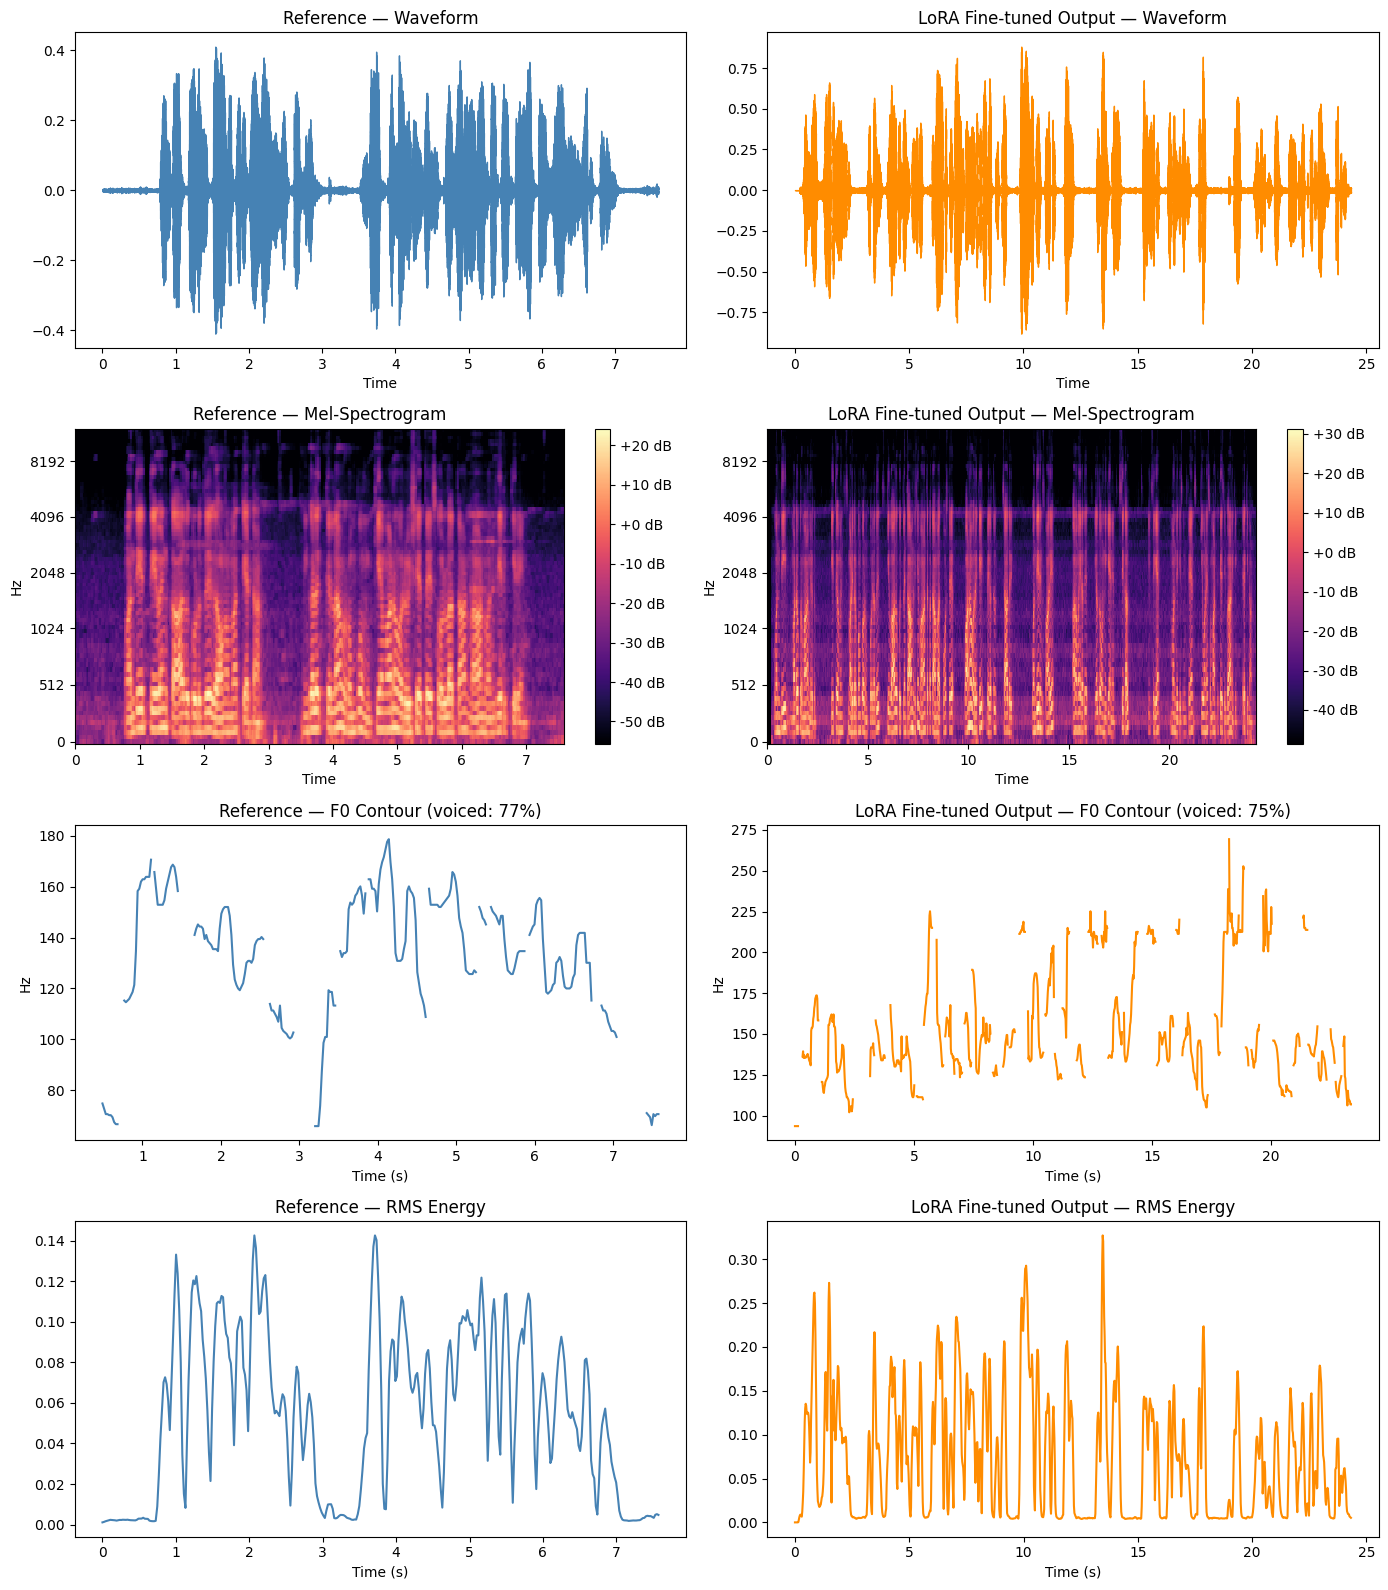


=== Voiced-frame ratio ===
Reference:      77.0%
LoRA-finetuned: 75.4%

=== Spectral centroid (Hz) ===
Reference: mean spectral centroid = 1347 Hz, std = 504 Hz
LoRA-finetuned: mean spectral centroid = 1484 Hz, std = 604 Hz

=== Duration ===
Reference:      7.59s
LoRA-finetuned: 24.33s


/kaggle/working/evaluation_graphs.png

In [30]:
# ===========================================================================
# 5. Evaluation graphs: Reference vs LoRA-fine-tuned output
# ===========================================================================
y_ref, sr_ref = librosa.load(REF_AUDIO, sr=24000)
y_gen, sr_gen = librosa.load(OUTPUT_WAV, sr=24000)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

def plot_col(col, y, sr, label, color):
    librosa.display.waveshow(y, sr=sr, ax=axes[0, col], color=color)
    axes[0, col].set_title(f"{label} — Waveform")

    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80), ref=1.0)
    img = librosa.display.specshow(mel, x_axis='time', y_axis='mel', sr=sr, cmap='magma', ax=axes[1, col])
    axes[1, col].set_title(f"{label} — Mel-Spectrogram")
    fig.colorbar(img, ax=axes[1, col], format='%+2.0f dB')

    f0, voiced_flag, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr)
    times = librosa.times_like(f0, sr=sr)
    axes[2, col].plot(times, f0, color=color, linewidth=1.5)
    voiced_pct = 100 * np.nanmean(voiced_flag)
    axes[2, col].set_title(f"{label} — F0 Contour (voiced: {voiced_pct:.0f}%)")
    axes[2, col].set_xlabel("Time (s)")
    axes[2, col].set_ylabel("Hz")

    rms = librosa.feature.rms(y=y)[0]
    axes[3, col].plot(librosa.times_like(rms, sr=sr), rms, color=color)
    axes[3, col].set_title(f"{label} — RMS Energy")
    axes[3, col].set_xlabel("Time (s)")

    return voiced_pct

voiced_ref = plot_col(0, y_ref, sr_ref, "Reference", "steelblue")
voiced_gen = plot_col(1, y_gen, sr_gen, "LoRA Fine-tuned Output", "darkorange")

plt.tight_layout()
plt.savefig("/kaggle/working/evaluation_graphs.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Voiced-frame ratio ===")
print(f"Reference:      {voiced_ref:.1f}%")
print(f"LoRA-finetuned: {voiced_gen:.1f}%")

def spectral_centroid_stats(y, sr, label):
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    print(f"{label}: mean spectral centroid = {np.mean(sc):.0f} Hz, std = {np.std(sc):.0f} Hz")

print("\n=== Spectral centroid (Hz) ===")
spectral_centroid_stats(y_ref, sr_ref, "Reference")
spectral_centroid_stats(y_gen, sr_gen, "LoRA-finetuned")

print("\n=== Duration ===")
print(f"Reference:      {len(y_ref)/sr_ref:.2f}s")
print(f"LoRA-finetuned: {len(y_gen)/sr_gen:.2f}s")

FileLink("/kaggle/working/evaluation_graphs.png")  # download the saved plot image too

Generated audio: 24.33s, split into 23 windows of 2.0s


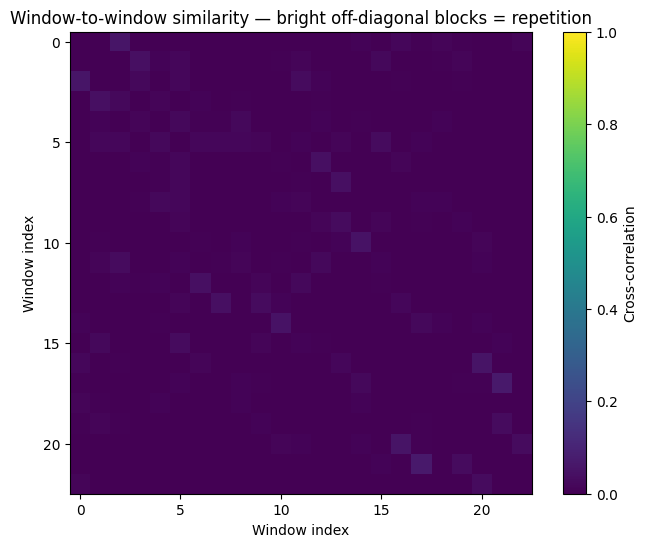


Max off-diagonal correlation: 0.067
(> ~0.7 between non-adjacent windows strongly suggests looping/repeated content)


In [31]:
import numpy as np
import librosa

# Chop the generated audio into fixed windows and cross-correlate them
# against each other — high correlation between non-adjacent windows
# is a strong signal of looping/repetition.
window_s = 2.0
hop_s = 1.0
window = int(window_s * sr_gen)
hop = int(hop_s * sr_gen)

n_windows = (len(y_gen) - window) // hop + 1
windows = [y_gen[i*hop : i*hop + window] for i in range(n_windows)]

print(f"Generated audio: {len(y_gen)/sr_gen:.2f}s, split into {n_windows} windows of {window_s}s")

corr_matrix = np.zeros((n_windows, n_windows))
for i in range(n_windows):
    for j in range(n_windows):
        if i != j:
            corr_matrix[i, j] = np.corrcoef(windows[i], windows[j])[0, 1]

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Cross-correlation")
plt.title("Window-to-window similarity — bright off-diagonal blocks = repetition")
plt.xlabel("Window index")
plt.ylabel("Window index")
plt.show()

max_offdiag = np.max(corr_matrix)
print(f"\nMax off-diagonal correlation: {max_offdiag:.3f}")
print("(> ~0.7 between non-adjacent windows strongly suggests looping/repeated content)")

In [32]:
# Compare against base model (no LoRA) on the exact same text/reference
with torch.no_grad():
    audio_base_check = base_model(gen_text, ref_audio_path=REF_AUDIO, ref_text=ref_text)

base_check_path = "/kaggle/working/base_no_lora_check.wav"
save_audio(audio_base_check, base_check_path)

y_base_check, sr_base_check = librosa.load(base_check_path, sr=24000)
print(f"Base model (no LoRA) duration for same text: {len(y_base_check)/sr_base_check:.2f}s")
print(f"LoRA fine-tuned duration for same text:       {len(y_gen)/sr_gen:.2f}s")
print(f"Reference clip duration:                       {len(y_ref)/sr_ref:.2f}s")

Base model (no LoRA) duration for same text: 23.55s
LoRA fine-tuned duration for same text:       24.33s
Reference clip duration:                       7.59s
